In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold

BASE_PATH = '/content/drive/My Drive/phishing project datasets/processed'
CV_PATH = f'{BASE_PATH}/cv_evaluation'
import os
os.makedirs(CV_PATH, exist_ok=True)

# use the full labeled pool (train+test combined) so CV folds are drawn fresh,
# not constrained by the earlier single train/test split
train_df = pd.read_csv(f'{BASE_PATH}/train_features.csv')
test_df = pd.read_csv(f'{BASE_PATH}/test_features.csv')
full_df = pd.concat([train_df, test_df], ignore_index=True).drop_duplicates(subset='email_id')

print(full_df.shape)
print(full_df['label'].value_counts(normalize=True))

Mounted at /content/drive


/tmp/ipykernel_983/4020767737.py:15: DtypeWarning: Columns (21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(f'{BASE_PATH}/train_features.csv')


(253227, 43)
label
0    0.98824
1    0.01176
Name: proportion, dtype: float64


In [2]:
SUBSAMPLE_SIZE = 35000
RANDOM_SEED = 42

subsample_df, _ = train_test_split_placeholder = (None, None)  # placeholder removed below

from sklearn.model_selection import train_test_split

subsample_df, _ = train_test_split(
    full_df,
    train_size=SUBSAMPLE_SIZE,
    stratify=full_df['label'],
    random_state=RANDOM_SEED
)

print("Subsample shape:", subsample_df.shape)
print("Subsample label counts:\n", subsample_df['label'].value_counts())
print("Subsample label proportions:\n", subsample_df['label'].value_counts(normalize=True))

Subsample shape: (35000, 43)
Subsample label counts:
 label
0    34588
1      412
Name: count, dtype: int64
Subsample label proportions:
 label
0    0.988229
1    0.011771
Name: proportion, dtype: float64


In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

subsample_df = subsample_df.reset_index(drop=True)
fold_assignments = np.zeros(len(subsample_df), dtype=int)

for fold_idx, (_, val_idx) in enumerate(skf.split(subsample_df, subsample_df['label'])):
    fold_assignments[val_idx] = fold_idx

subsample_df['cv_fold'] = fold_assignments

print(subsample_df.groupby('cv_fold')['label'].value_counts())

cv_fold  label
0        0        6918
         1          82
1        0        6918
         1          82
2        0        6918
         1          82
3        0        6917
         1          83
4        0        6917
         1          83
Name: count, dtype: int64


In [4]:
output_cols = ['email_id', 'label', 'cv_fold']
subsample_df[output_cols].to_csv(f'{CV_PATH}/cv_fold_assignments.csv', index=False)

# also save the full subsample row data, since we'll need text/features without re-deriving everything each time
subsample_df.to_csv(f'{CV_PATH}/cv_subsample_full.csv', index=False)

print(f"Saved fold assignments and full subsample to {CV_PATH}")
print(subsample_df.shape)

Saved fold assignments and full subsample to /content/drive/My Drive/phishing project datasets/processed/cv_evaluation
(35000, 44)


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import time

BASE_PATH = '/content/drive/My Drive/phishing project datasets/processed'
CV_PATH = f'{BASE_PATH}/cv_evaluation'

subsample_df = pd.read_csv(f'{CV_PATH}/cv_subsample_full.csv')

# rebuild subject + text (subject was never persisted, same recurring fix as every prior session)
enron_subj = pd.read_csv(f'{BASE_PATH}/enron_emails_cleaned_temporal.csv', usecols=['message_id', 'subject']).rename(columns={'message_id': 'email_id'})
nazario_raw = pd.read_csv(f'{BASE_PATH}/nazario5_cleaned_temporal.csv', usecols=['sender_address', 'utc_datetime', 'subject'])
nazario_raw['utc_datetime'] = pd.to_datetime(nazario_raw['utc_datetime'], errors='coerce')
nazario_raw['sender_norm'] = nazario_raw['sender_address'].astype(str).str.strip().str.lower()
nazario_raw['email_id'] = nazario_raw['sender_norm'] + '_' + nazario_raw['utc_datetime'].astype(str)
nazario_subj = nazario_raw[['email_id', 'subject']]
subjects_all = pd.concat([enron_subj, nazario_subj], ignore_index=True).drop_duplicates(subset='email_id')

subsample_df = subsample_df.merge(subjects_all, on='email_id', how='left')
subsample_df['text'] = "[SUBJECT] " + subsample_df['subject'].fillna('') + " [BODY] " + subsample_df['body_text'].fillna('')

del enron_subj, nazario_raw, nazario_subj, subjects_all
print(subsample_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_983/3752425613.py:11: DtypeWarning: Columns (21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  subsample_df = pd.read_csv(f'{CV_PATH}/cv_subsample_full.csv')


(35000, 46)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

TRAD_MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
    'LinearSVC': CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=2000)),  # calibrated for predict_proba (needed for AUC-ROC)
    'MultinomialNB': MultinomialNB(),
}

trad_results = []
t0 = time.time()

for fold in range(5):
    train_mask = subsample_df['cv_fold'] != fold
    test_mask = subsample_df['cv_fold'] == fold

    tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
    X_train = tfidf.fit_transform(subsample_df.loc[train_mask, 'text'])
    X_test = tfidf.transform(subsample_df.loc[test_mask, 'text'])
    y_train = subsample_df.loc[train_mask, 'label'].values
    y_test = subsample_df.loc[test_mask, 'label'].values

    for model_name, model in TRAD_MODELS.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

        trad_results.append({
            'model': model_name, 'fold': fold,
            'accuracy': accuracy_score(y_test, preds),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall': recall_score(y_test, preds, zero_division=0),
            'f1': f1_score(y_test, preds, zero_division=0),
            'roc_auc': roc_auc_score(y_test, probs),
        })
    print(f"Fold {fold} done. Elapsed: {(time.time()-t0)/60:.1f} min")

trad_results_df = pd.DataFrame(trad_results)
trad_results_df.to_csv(f'{CV_PATH}/traditional_ml_cv_results.csv', index=False)

print("\n=== Summary (mean ± std across 5 folds) ===")
print(trad_results_df.groupby('model')[['accuracy','precision','recall','f1','roc_auc']].agg(['mean','std']))

Fold 0 done. Elapsed: 1.2 min
Fold 1 done. Elapsed: 2.1 min
Fold 2 done. Elapsed: 3.0 min
Fold 3 done. Elapsed: 3.9 min
Fold 4 done. Elapsed: 4.8 min

=== Summary (mean ± std across 5 folds) ===
                    accuracy           precision              recall  \
                        mean       std      mean       std      mean   
model                                                                  
LinearSVC           0.994429  0.001005  0.890344  0.035425  0.599618   
LogisticRegression  0.989400  0.001032  0.535825  0.031459  0.769409   
MultinomialNB       0.987800  0.000652  0.455644  0.069958  0.165060   
RandomForest        0.991686  0.000433  0.954001  0.032326  0.308228   

                                    f1             roc_auc            
                         std      mean       std      mean       std  
model                                                                 
LinearSVC           0.068116  0.715648  0.058162  0.963242  0.012303  
LogisticRegressi

In [7]:
import torch
import torch.nn as nn
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LENGTH = 256

def run_transformer_cv(checkpoint_name, model_label):
    results = []
    tokenizer = AutoTokenizer.from_pretrained(checkpoint_name)

    for fold in range(5):
        t0 = time.time()
        train_data = subsample_df[subsample_df['cv_fold'] != fold][['text', 'label']].reset_index(drop=True)
        test_data = subsample_df[subsample_df['cv_fold'] == fold][['text', 'label']].reset_index(drop=True)

        class_counts = train_data['label'].value_counts().sort_index()
        total = class_counts.sum()
        class_weights = torch.tensor([total/(2*c) for c in class_counts], dtype=torch.float32).to(device)

        train_ds = Dataset.from_pandas(train_data, preserve_index=False)
        test_ds = Dataset.from_pandas(test_data, preserve_index=False)

        def tok_fn(batch):
            return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

        train_ds = train_ds.map(tok_fn, batched=True, batch_size=1000, remove_columns=['text'])
        test_ds = test_ds.map(tok_fn, batched=True, batch_size=1000, remove_columns=['text'])
        train_ds = train_ds.rename_column('label', 'labels')
        test_ds = test_ds.rename_column('label', 'labels')

        data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

        model = AutoModelForSequenceClassification.from_pretrained(checkpoint_name, num_labels=2).to(device)

        class WeightedTrainer(Trainer):
            def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
                labels = inputs.pop("labels")
                outputs = model(**inputs)
                loss = nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
                return (loss, outputs) if return_outputs else loss

        args = TrainingArguments(
            output_dir=f'{CV_PATH}/tmp_{model_label}_fold{fold}',
            per_device_train_batch_size=8, per_device_eval_batch_size=16,
            gradient_accumulation_steps=4, num_train_epochs=1,
            fp16=torch.cuda.is_available(),
            eval_strategy="no", save_strategy="no",
            logging_steps=500, report_to="none", dataloader_num_workers=0,
        )

        trainer = WeightedTrainer(model=model, args=args, train_dataset=train_ds, data_collator=data_collator)
        trainer.train()

        preds_out = trainer.predict(test_ds)
        logits = preds_out.predictions
        labels = preds_out.label_ids
        probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
        preds = logits.argmax(axis=1)

        results.append({
            'model': model_label, 'fold': fold,
            'accuracy': accuracy_score(labels, preds),
            'precision': precision_score(labels, preds, zero_division=0),
            'recall': recall_score(labels, preds, zero_division=0),
            'f1': f1_score(labels, preds, zero_division=0),
            'roc_auc': roc_auc_score(labels, probs),
        })

        del model, trainer
        gc.collect()
        torch.cuda.empty_cache()

        print(f"  {model_label} fold {fold} done in {(time.time()-t0)/60:.1f} min")

    return results

print("Function ready.")

Function ready.


In [8]:
all_transformer_results = []

for checkpoint, label in [
    ('distilbert-base-uncased', 'DistilBERT'),
    ('bert-base-uncased', 'BERT'),
    ('roberta-base', 'RoBERTa'),
]:
    print(f"\n=== Running {label} ===")
    all_transformer_results.extend(run_transformer_cv(checkpoint, label))

transformer_results_df = pd.DataFrame(all_transformer_results)
transformer_results_df.to_csv(f'{CV_PATH}/transformer_cv_results.csv', index=False)

print("\n=== Summary (mean ± std across 5 folds) ===")
print(transformer_results_df.groupby('model')[['accuracy','precision','recall','f1','roc_auc']].agg(['mean','std']))


=== Running DistilBERT ===


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,1.522526


  RoBERTa fold 4 done in 7.9 min

=== Summary (mean ± std across 5 folds) ===
            accuracy           precision              recall            \
                mean       std      mean       std      mean       std   
model                                                                    
BERT        0.993914  0.002751   0.88754  0.078529  0.558008  0.245664   
DistilBERT  0.994114  0.002044   0.85998  0.110952  0.592036  0.142131   
RoBERTa     0.992543  0.003336   0.75138  0.420215  0.390949  0.299533   

                  f1             roc_auc            
                mean       std      mean       std  
model                                               
BERT        0.652031  0.243335  0.927882  0.035123  
DistilBERT  0.696638  0.130624  0.939029  0.020558  
RoBERTa     0.491424  0.343344  0.810001  0.213697  


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import time, gc, os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from transformers import AutoTokenizer, DistilBertModel, Trainer, TrainingArguments

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_PATH = '/content/drive/My Drive/phishing project datasets/processed'
CV_PATH = f'{BASE_PATH}/cv_evaluation'
MAX_LENGTH = 256

# reload the saved subsample (built earlier, persists on Drive regardless of runtime disconnect)
subsample_df = pd.read_csv(f'{CV_PATH}/cv_subsample_full.csv')

# rebuild subject + text
enron_subj = pd.read_csv(f'{BASE_PATH}/enron_emails_cleaned_temporal.csv', usecols=['message_id', 'subject']).rename(columns={'message_id': 'email_id'})
nazario_raw = pd.read_csv(f'{BASE_PATH}/nazario5_cleaned_temporal.csv', usecols=['sender_address', 'utc_datetime', 'subject'])
nazario_raw['utc_datetime'] = pd.to_datetime(nazario_raw['utc_datetime'], errors='coerce')
nazario_raw['sender_norm'] = nazario_raw['sender_address'].astype(str).str.strip().str.lower()
nazario_raw['email_id'] = nazario_raw['sender_norm'] + '_' + nazario_raw['utc_datetime'].astype(str)
nazario_subj = nazario_raw[['email_id', 'subject']]
subjects_all = pd.concat([enron_subj, nazario_subj], ignore_index=True).drop_duplicates(subset='email_id')

subsample_df = subsample_df.merge(subjects_all, on='email_id', how='left')
subsample_df['text'] = "[SUBJECT] " + subsample_df['subject'].fillna('') + " [BODY] " + subsample_df['body_text'].fillna('')
del enron_subj, nazario_raw, nazario_subj, subjects_all
gc.collect()

# temporal features + sequences
def prep_temporal_features(df):
    df = df.copy()
    df['log_interarrival'] = np.log1p(df['interarrival_hours'].fillna(0).clip(lower=0))
    df['hour_sin'] = np.sin(2*np.pi*df['hour_of_day_utc']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour_of_day_utc']/24)
    df['day_sin'] = np.sin(2*np.pi*df['day_of_week']/7)
    df['day_cos'] = np.cos(2*np.pi*df['day_of_week']/7)
    df['is_weekend'] = df['is_weekend'].astype(float)
    df['is_burst_anomaly'] = df['is_burst_anomaly'].astype(float)
    df['temporal_anomaly'] = df['temporal_anomaly'].fillna(False).astype(float)
    df['sender'] = df['sender'].fillna('__unknown_sender__')
    return df

SEQ_FEATURES = ['log_interarrival','hour_sin','hour_cos','day_sin','day_cos','is_weekend','is_burst_anomaly','temporal_anomaly']
MAX_SEQ_LEN = 10

def build_sequences(df, seq_features=SEQ_FEATURES, max_len=MAX_SEQ_LEN):
    df2 = df.sort_values(['sender','datetime']).reset_index(drop=True)
    feat_matrix = df2[seq_features].values.astype(np.float32)
    n = len(df2)
    sequences = np.zeros((n, max_len, len(seq_features)), dtype=np.float32)
    lengths = np.zeros(n, dtype=np.int64)
    for _, idx_group in df2.groupby('sender').indices.items():
        idx_group = np.sort(idx_group)
        for pos, row_idx in enumerate(idx_group):
            start = max(0, pos - max_len + 1)
            window_idx = idx_group[start:pos+1]
            L = len(window_idx)
            sequences[row_idx, :L, :] = feat_matrix[window_idx]
            lengths[row_idx] = L
    lengths = np.maximum(lengths, 1)
    return sequences, lengths, df2['email_id'].values

def reindex_to(target_ids, source_ids, *arrays):
    pos = {eid: i for i, eid in enumerate(source_ids)}
    order = [pos[eid] for eid in target_ids]
    return tuple(arr[order] for arr in arrays)

subsample_df = prep_temporal_features(subsample_df)
seq_raw, lens_raw, ids_seq = build_sequences(subsample_df)
sub_seq, sub_seq_lens = reindex_to(subsample_df['email_id'].values, ids_seq, seq_raw, lens_raw)

# behavioral columns
BEHAVIORAL_COLS = [
    'domain_age_days', 'domain_reputation_score', 'tld_risk_weight',
    'has_dmarc_record', 'dmarc_enforced', 'spf_pass', 'dkim_pass',
    'ip_is_residential_proxy', 'ip_is_vpn_or_anon', 'ip_is_datacenter', 'ip_reputation_score',
    'sender_email_count', 'sender_active_days', 'sender_avg_daily_volume',
    'unique_recipient_count', 'is_repeat_correspondent', 'recipient_reuse_ratio', 'sender_prior_unique_recipients',
    'has_url', 'is_ip_based', 'subdomain_count', 'path_length', 'query_param_count', 'url_length', 'uses_https',
]

def clean_behavioral(df):
    df = df.copy()
    df['domain_unknown'] = df['domain_age_days'].isna().astype(float)
    for col in ['has_dmarc_record','dmarc_enforced','spf_pass','dkim_pass']:
        df[col] = df[col].fillna(False).astype(float)
    for col in ['is_ip_based','subdomain_count','path_length','query_param_count','url_length','uses_https']:
        df[col] = df[col].fillna(0).astype(float)
    for col in ['ip_is_residential_proxy','ip_is_vpn_or_anon','ip_is_datacenter','is_repeat_correspondent']:
        df[col] = df[col].astype(float)
    return df

FINAL_BEHAVIORAL_COLS = BEHAVIORAL_COLS + ['domain_unknown']
subsample_df = clean_behavioral(subsample_df)

print("Setup complete:", subsample_df.shape, sub_seq.shape)

Mounted at /content/drive


/tmp/ipykernel_2976/1296317361.py:19: DtypeWarning: Columns (21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  subsample_df = pd.read_csv(f'{CV_PATH}/cv_subsample_full.csv')


Setup complete: (35000, 52) (35000, 10, 8)


/tmp/ipykernel_2976/1296317361.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(float)
/tmp/ipykernel_2976/1296317361.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(float)
/tmp/ipykernel_2976/1296317361.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)

In [2]:
class TemporalLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return h_n[-1]

class BehavioralFFN(nn.Module):
    def __init__(self, input_dim=26, hidden_dims=(64, 32)):
        super().__init__()
        self.hidden1 = nn.Sequential(nn.Linear(input_dim, hidden_dims[0]), nn.ReLU(), nn.Dropout(0.2))
        self.hidden2 = nn.Sequential(nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(), nn.Dropout(0.2))
    def forward(self, x):
        return self.hidden2(self.hidden1(x))

class FusionModelFresh(nn.Module):
    def __init__(self, class_weights):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.lstm = TemporalLSTM()
        self.ffn = BehavioralFFN()
        self.fusion_head = nn.Sequential(nn.Linear(768+64+32, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2))
        self.register_buffer('class_weights', class_weights)

    def mean_pool(self, last_hidden, mask):
        mask = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        return torch.sum(last_hidden*mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)

    def forward(self, input_ids, attention_mask, seq, seq_lengths, behav, labels=None):
        ctx = self.mean_pool(self.distilbert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state, attention_mask)
        temp = self.lstm(seq, seq_lengths)
        beh = self.ffn(behav)
        logits = self.fusion_head(torch.cat([ctx, temp, beh], dim=1))
        out = {'logits': logits}
        if labels is not None:
            out['loss'] = nn.CrossEntropyLoss(weight=self.class_weights)(logits, labels)
        return out

class FusionDatasetCV(torch.utils.data.Dataset):
    def __init__(self, texts, seqs, seq_lens, behav, labels):
        self.texts, self.seqs, self.seq_lens, self.behav, self.labels = texts, seqs, seq_lens, behav, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {'text': self.texts[idx], 'seq': self.seqs[idx], 'seq_len': self.seq_lens[idx],
                'behav': self.behav[idx], 'label': self.labels[idx]}

fusion_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def fusion_collate(batch):
    enc = fusion_tokenizer([b['text'] for b in batch], truncation=True, max_length=MAX_LENGTH, padding=True, return_tensors='pt')
    seq = torch.tensor(np.stack([b['seq'] for b in batch]), dtype=torch.float32)
    seq_len = torch.tensor([b['seq_len'] for b in batch], dtype=torch.long)
    behav = torch.tensor(np.stack([b['behav'] for b in batch]), dtype=torch.float32)
    labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)
    return {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask'],
            'seq': seq, 'seq_lengths': seq_len, 'behav': behav, 'labels': labels}

class FusionCollatorCV:
    def __call__(self, features): return fusion_collate(features)

class FusionTrainerCV(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        out = model(**inputs)
        return (out['loss'], out) if return_outputs else out['loss']
    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        labels = inputs.get('labels')
        with torch.no_grad():
            out = model(**inputs)
        return (out.get('loss'), out['logits'], labels)

def has_nan_weights(model):
    return any(torch.isnan(p).any() for p in model.parameters())

fusion_results = []

for fold in range(5):
    t0 = time.time()
    train_mask = (subsample_df['cv_fold'] != fold).values
    test_mask = (subsample_df['cv_fold'] == fold).values

    scaler_fold = StandardScaler()
    behav_train = scaler_fold.fit_transform(subsample_df.loc[train_mask, FINAL_BEHAVIORAL_COLS].values.astype(np.float32))
    behav_test = scaler_fold.transform(subsample_df.loc[test_mask, FINAL_BEHAVIORAL_COLS].values.astype(np.float32))
    # guard against any inf/nan from zero-variance columns in this fold's split
    behav_train = np.nan_to_num(behav_train, nan=0.0, posinf=0.0, neginf=0.0)
    behav_test = np.nan_to_num(behav_test, nan=0.0, posinf=0.0, neginf=0.0)

    train_ds_f = FusionDatasetCV(
        subsample_df.loc[train_mask, 'text'].tolist(), sub_seq[train_mask], sub_seq_lens[train_mask],
        behav_train, subsample_df.loc[train_mask, 'label'].values)
    test_ds_f = FusionDatasetCV(
        subsample_df.loc[test_mask, 'text'].tolist(), sub_seq[test_mask], sub_seq_lens[test_mask],
        behav_test, subsample_df.loc[test_mask, 'label'].values)

    cc = subsample_df.loc[train_mask, 'label'].value_counts().sort_index()
    cw = torch.tensor([cc.sum()/(2*c) for c in cc], dtype=torch.float32).to(device)

    model = FusionModelFresh(cw).to(device)

    args = TrainingArguments(
        output_dir=f'{CV_PATH}/tmp_fusion_fold{fold}',
        per_device_train_batch_size=4, per_device_eval_batch_size=8,
        gradient_accumulation_steps=8, num_train_epochs=1,
        fp16=False,                      # disabled -- fp16 + LSTM caused the NaN crash
        max_grad_norm=1.0,               # explicit gradient clipping
        learning_rate=3e-5,              # slightly lower than default for stability
        eval_strategy="no", save_strategy="no", logging_steps=500,
        report_to="none", dataloader_num_workers=0, remove_unused_columns=False, label_names=["labels"],
    )
    trainer = FusionTrainerCV(model=model, args=args, train_dataset=train_ds_f, data_collator=FusionCollatorCV())
    trainer.train()

    if has_nan_weights(model):
        print(f"  WARNING: fold {fold} produced NaN weights even without fp16. Skipping metrics for this fold.")
        fusion_results.append({'model': 'Fusion', 'fold': fold, 'accuracy': np.nan, 'precision': np.nan,
                                'recall': np.nan, 'f1': np.nan, 'roc_auc': np.nan})
    else:
        preds_out = trainer.predict(test_ds_f)
        logits, labels = preds_out.predictions, preds_out.label_ids
        probs = torch.softmax(torch.tensor(logits), dim=1)[:,1].numpy()
        preds = logits.argmax(axis=1)

        fusion_results.append({
            'model': 'Fusion', 'fold': fold,
            'accuracy': accuracy_score(labels, preds), 'precision': precision_score(labels, preds, zero_division=0),
            'recall': recall_score(labels, preds, zero_division=0), 'f1': f1_score(labels, preds, zero_division=0),
            'roc_auc': roc_auc_score(labels, probs),
        })

    del model, trainer
    gc.collect(); torch.cuda.empty_cache()
    print(f"Fusion fold {fold} done in {(time.time()-t0)/60:.1f} min")

fusion_results_df = pd.DataFrame(fusion_results)
fusion_results_df.to_csv(f'{CV_PATH}/fusion_cv_results.csv', index=False)
print("\n=== Fusion Summary ===")
print(fusion_results_df[['accuracy','precision','recall','f1','roc_auc']].agg(['mean','std']))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

...

Fusion fold 3 done in 13.3 min


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
500,0.135127


Fusion fold 4 done in 13.3 min

=== Fusion Summary ===
      accuracy  precision    recall        f1   roc_auc
mean  0.994600   0.855415  0.653012  0.739703  0.948809
std   0.001158   0.065114  0.060970  0.057290  0.012953


In [3]:
trad_df = pd.read_csv(f'{CV_PATH}/traditional_ml_cv_results.csv')
trans_df = pd.read_csv(f'{CV_PATH}/transformer_cv_results.csv')
fusion_df = pd.read_csv(f'{CV_PATH}/fusion_cv_results.csv')

all_results = pd.concat([trad_df, trans_df, fusion_df], ignore_index=True)
all_results.to_csv(f'{CV_PATH}/all_models_cv_results.csv', index=False)

summary = all_results.groupby('model')[['accuracy','precision','recall','f1','roc_auc']].agg(['mean','std'])
summary = summary.sort_values(('f1','mean'), ascending=False)
print(summary)

                    accuracy           precision              recall  \
                        mean       std      mean       std      mean   
model                                                                  
Fusion              0.994600  0.001158  0.855415  0.065114  0.653012   
LinearSVC           0.994429  0.001005  0.890344  0.035425  0.599618   
DistilBERT          0.994114  0.002044  0.859980  0.110952  0.592036   
BERT                0.993914  0.002751  0.887540  0.078529  0.558008   
LogisticRegression  0.989400  0.001032  0.535825  0.031459  0.769409   
RoBERTa             0.992543  0.003336  0.751380  0.420215  0.390949   
RandomForest        0.991686  0.000433  0.954001  0.032326  0.308228   
MultinomialNB       0.987800  0.000652  0.455644  0.069958  0.165060   

                                    f1             roc_auc            
                         std      mean       std      mean       std  
model                                                            

In [4]:
from scipy.stats import wilcoxon

def get_fold_vector(df, model_name, metric):
    return df[df['model'] == model_name].sort_values('fold')[metric].values

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
other_models = [m for m in all_results['model'].unique() if m != 'Fusion']

sig_results = []
fusion_vectors = {m: get_fold_vector(all_results, 'Fusion', m) for m in metrics}

for model in other_models:
    for metric in metrics:
        fusion_vals = fusion_vectors[metric]
        other_vals = get_fold_vector(all_results, model, metric)
        diff = fusion_vals - other_vals

        if np.allclose(diff, 0):
            stat, p = np.nan, 1.0  # identical across all folds, no meaningful test
        else:
            stat, p = wilcoxon(fusion_vals, other_vals)

        sig_results.append({
            'comparison': f'Fusion vs {model}', 'metric': metric,
            'fusion_mean': fusion_vals.mean(), 'other_mean': other_vals.mean(),
            'diff': fusion_vals.mean() - other_vals.mean(),
            'wilcoxon_stat': stat, 'p_value': p,
            'significant_at_0.05': p < 0.05
        })

sig_df = pd.DataFrame(sig_results)
sig_df.to_csv(f'{CV_PATH}/significance_tests.csv', index=False)

pd.set_option('display.max_rows', None)
print(sig_df[sig_df['metric'] == 'f1'].to_string(index=False))

                  comparison metric  fusion_mean  other_mean     diff  wilcoxon_stat  p_value  significant_at_0.05
Fusion vs LogisticRegression     f1     0.739703    0.630978 0.108725            0.0   0.0625                False
      Fusion vs RandomForest     f1     0.739703    0.465573 0.274130            0.0   0.0625                False
         Fusion vs LinearSVC     f1     0.739703    0.715648 0.024055            4.0   0.4375                False
     Fusion vs MultinomialNB     f1     0.739703    0.241787 0.497916            0.0   0.0625                False
        Fusion vs DistilBERT     f1     0.739703    0.696638 0.043064            6.0   0.8125                False
              Fusion vs BERT     f1     0.739703    0.652031 0.087672            5.0   0.6250                False
           Fusion vs RoBERTa     f1     0.739703    0.491424 0.248279            1.0   0.1250                False


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style('whitegrid')
CHART_PATH = f'{CV_PATH}/charts'
import os
os.makedirs(CHART_PATH, exist_ok=True)

all_results = pd.read_csv(f'{CV_PATH}/all_models_cv_results.csv')
sig_df = pd.read_csv(f'{CV_PATH}/significance_tests.csv')

summary = all_results.groupby('model')[['accuracy','precision','recall','f1','roc_auc']].agg(['mean','std'])
summary = summary.sort_values(('f1','mean'), ascending=False)
model_order = summary.index.tolist()
print(model_order)

['Fusion', 'LinearSVC', 'DistilBERT', 'BERT', 'LogisticRegression', 'RoBERTa', 'RandomForest', 'MultinomialNB']


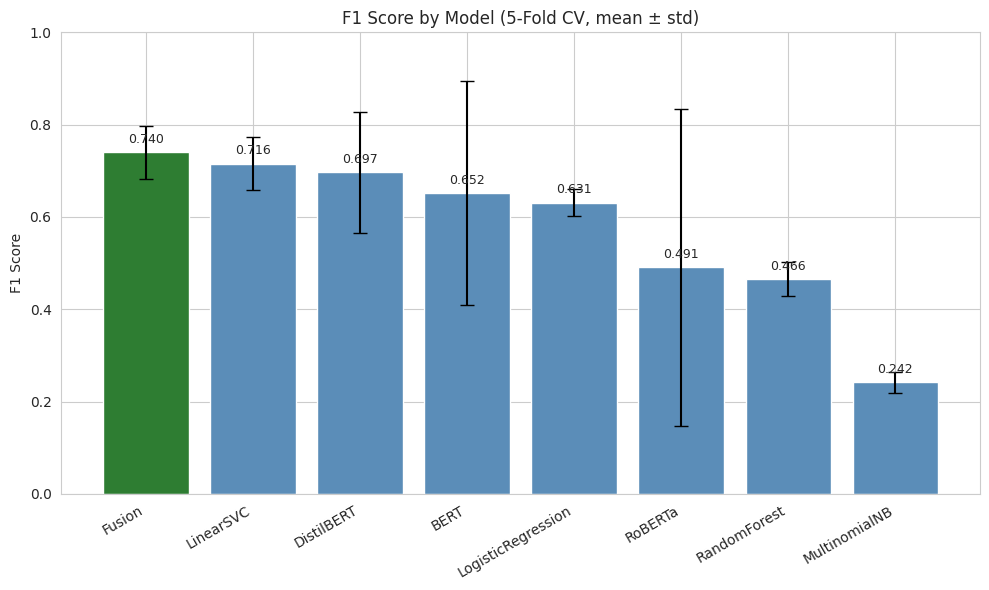

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
means = summary[('f1', 'mean')]
stds = summary[('f1', 'std')]
colors = ['#2E7D32' if m == 'Fusion' else '#5B8DB8' for m in model_order]

bars = ax.bar(model_order, means, yerr=stds, capsize=5, color=colors)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score by Model (5-Fold CV, mean ± std)')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.02, f'{mean:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/f1_comparison.png', dpi=150)
plt.show()

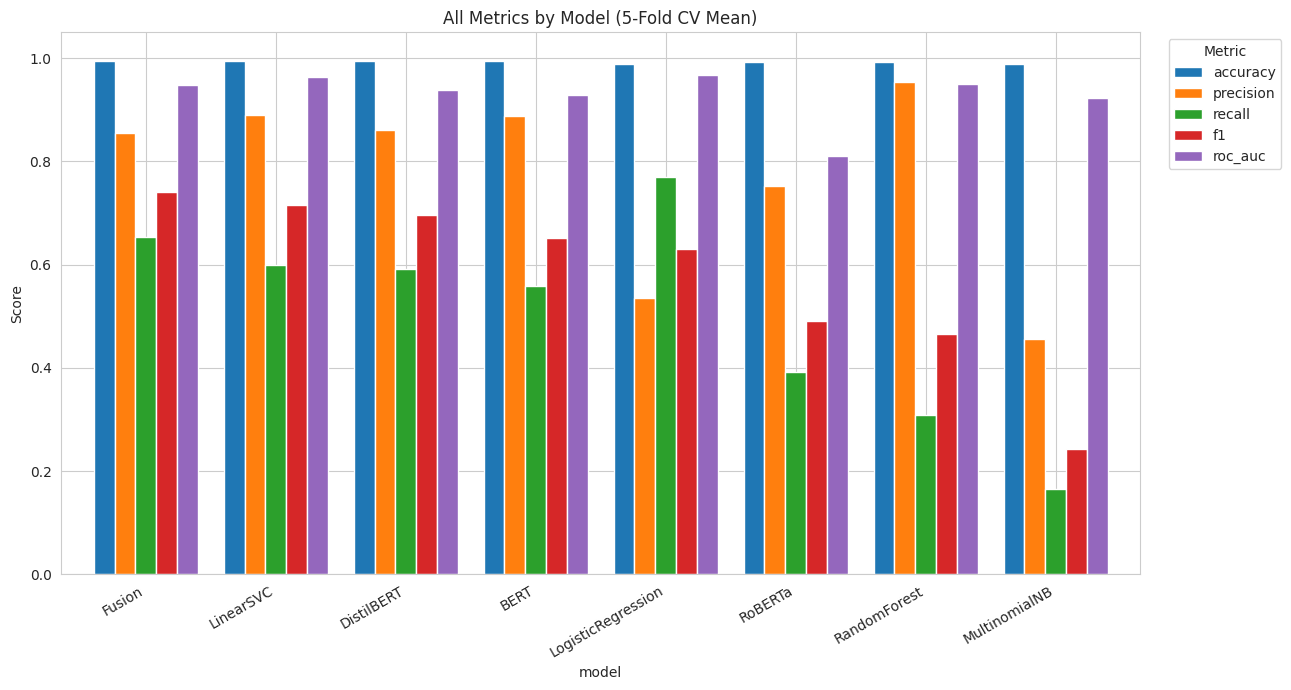

In [7]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
mean_table = summary.xs('mean', axis=1, level=1)[metrics]

fig, ax = plt.subplots(figsize=(13, 7))
mean_table.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Score')
ax.set_title('All Metrics by Model (5-Fold CV Mean)')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/all_metrics_comparison.png', dpi=150)
plt.show()

/tmp/ipykernel_2976/17450357.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='model', y='f1', order=model_order, ax=ax, palette='Blues')


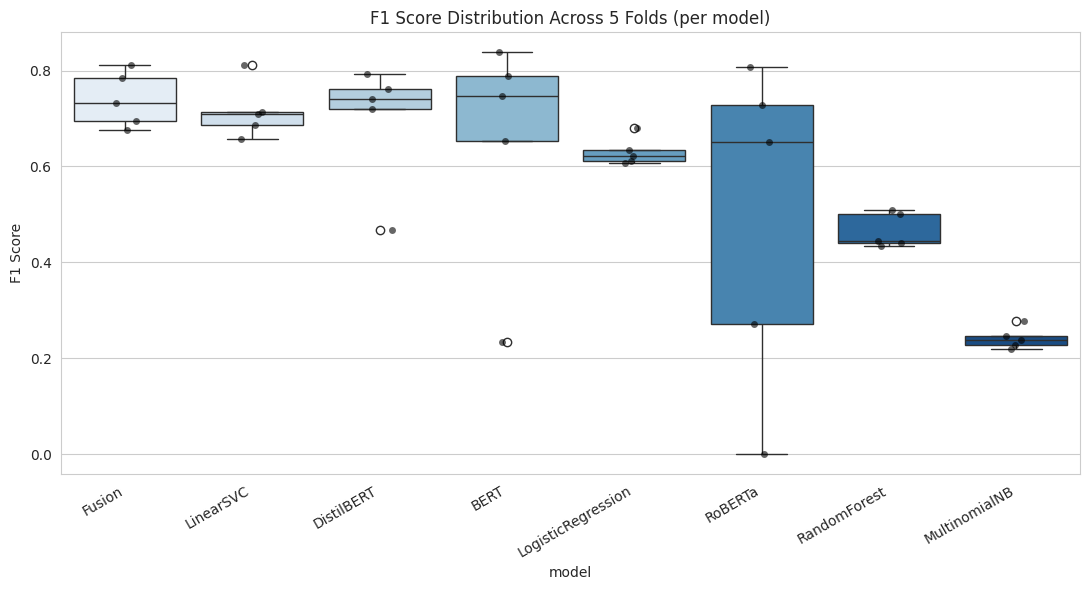

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = all_results.copy()
plot_data['model'] = pd.Categorical(plot_data['model'], categories=model_order, ordered=True)

sns.boxplot(data=plot_data, x='model', y='f1', order=model_order, ax=ax, palette='Blues')
sns.stripplot(data=plot_data, x='model', y='f1', order=model_order, ax=ax, color='black', size=5, alpha=0.6)
ax.set_title('F1 Score Distribution Across 5 Folds (per model)')
ax.set_ylabel('F1 Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/f1_fold_variance_boxplot.png', dpi=150)
plt.show()

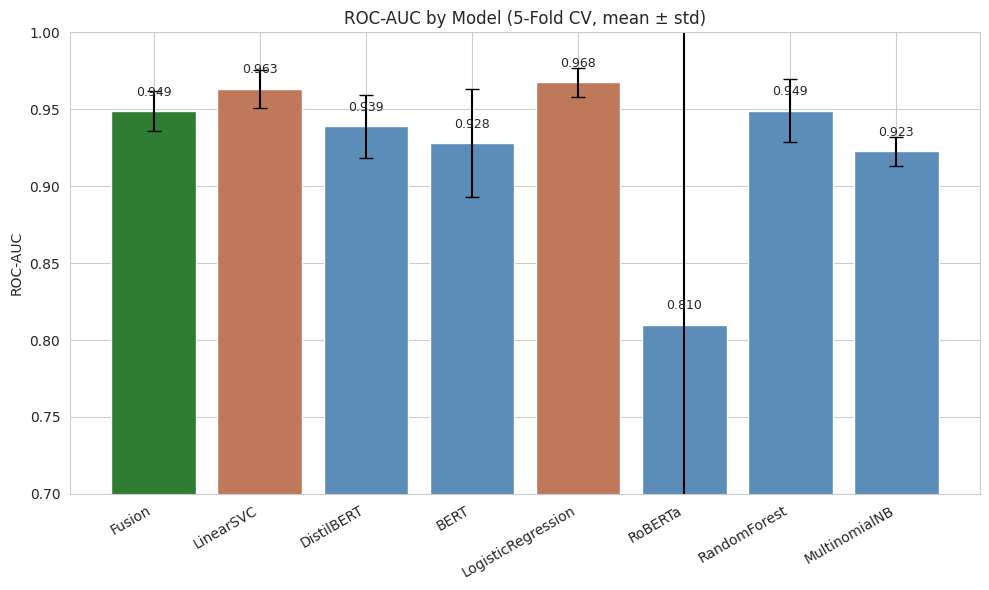

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
means_auc = summary[('roc_auc', 'mean')]
stds_auc = summary[('roc_auc', 'std')]
colors_auc = ['#2E7D32' if m == 'Fusion' else '#C0785A' if m in ['LogisticRegression','LinearSVC'] else '#5B8DB8' for m in model_order]

bars = ax.bar(model_order, means_auc, yerr=stds_auc, capsize=5, color=colors_auc)
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC by Model (5-Fold CV, mean ± std)')
ax.set_ylim(0.7, 1.0)
plt.xticks(rotation=30, ha='right')
for bar, mean in zip(bars, means_auc):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.01, f'{mean:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/roc_auc_comparison.png', dpi=150)
plt.show()

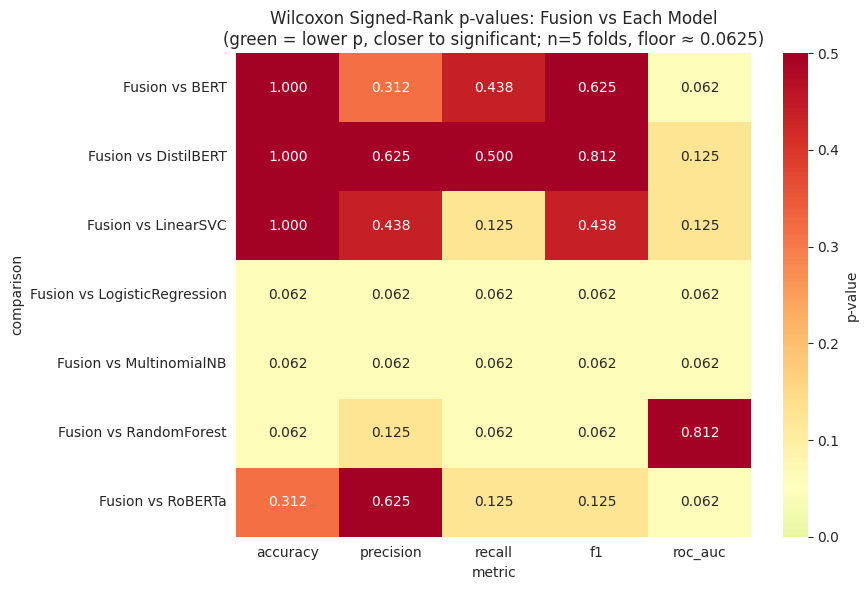

In [10]:
pivot = sig_df.pivot(index='comparison', columns='metric', values='p_value')
pivot = pivot[metrics]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0.05, vmin=0, vmax=0.5,
            cbar_kws={'label': 'p-value'}, ax=ax)
ax.set_title('Wilcoxon Signed-Rank p-values: Fusion vs Each Model\n(green = lower p, closer to significant; n=5 folds, floor ≈ 0.0625)')
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/significance_heatmap.png', dpi=150)
plt.show()